# 02 - Preprocessing & Feature Engineering

## Steps
1. Loaded cleaned data — 1567 chips, 446 features
2. Split data — 80% train, 20% test (stratified)
3. Scaled features — StandardScaler (mean=0, std=1)
4. Feature selection — SelectKBest f_classif, kept top 100
5. Handled class imbalance — SMOTE on training data only

## Key Decisions
- Stratified split to preserve 93/7 ratio in both sets
- Fit scaler on training data only — prevent data leakage
- SMOTE applied only on training data — test set stays real
- Reduced from 446 to 100 features — removed noise

## Final Data Shape
- Training: 2340 samples, 100 features, perfectly balanced
- Test: 314 samples, 100 features, real world distribution

## PREPROCESSING COMPLETE SUMMARY

Original features:        590
After cleaning:           446
After feature selection:  100

## Training samples (SMOTE): 2340
## Test samples (real):      314

## Training class balance:
  Fail: 1170 | Pass: 1170

## Test class balance:
  Fail: 293 | Pass: 21

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

X = pd.read_csv('../data/processed/secom_features_cleaned.csv')
y = pd.read_csv('../data/processed/secom_labels_cleaned.csv').squeeze()

print("Features shape:", X.shape)
print("Labels shape:", y.shape)
print("\nLabel distribution:")
print(y.value_counts())

Features shape: (1567, 446)
Labels shape: (1567,)

Label distribution:
label
0    1463
1     104
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=69,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTest label distribution:")
print(y_test.value_counts())

Training set: (1253, 446)
Test set: (314, 446)

Training label distribution:
label
0    1170
1      83
Name: count, dtype: int64

Test label distribution:
label
0    293
1     21
Name: count, dtype: int64


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set mean (should be ~0):", X_train_scaled.mean().round(4))
print("Training set std (should be ~1):", X_train_scaled.std().round(4))

Training set mean (should be ~0): 0.0
Training set std (should be ~1): 1.0


In [4]:
from sklearn.feature_selection import SelectKBest, f_classif

#top 100 most statistically significant features
selector = SelectKBest(f_classif, k=100)
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    'feature': range(X_train_scaled.shape[1]),
    'score': selector.scores_,
    'pvalue': selector.pvalues_
})

# Sort by score
feature_scores = feature_scores.sort_values('score', ascending=False)

print("Top 20 most important features:")
print(feature_scores.head(20))

Top 20 most important features:
     feature      score        pvalue
54        54  30.712400  3.645656e-08
388      388  25.936903  4.068747e-07
93        93  24.908753  6.859593e-07
331      331  23.670693  1.288587e-06
334      334  19.649215  1.011956e-05
330      330  18.948272  1.452661e-05
335      335  18.523305  1.809312e-05
336      336  17.828533  2.592227e-05
137      137  17.289795  3.427735e-05
230      230  16.453012  5.295617e-05
26        26  15.174242  1.032171e-04
19        19  14.987874  1.137932e-04
277      277  14.874106  1.207798e-04
146      146  14.471524  1.491651e-04
205      205  14.396025  1.551949e-04
300      300  14.326729  1.609454e-04
239      239  14.114547  1.799255e-04
101      101  14.020619  1.890337e-04
236      236  13.826191  2.093935e-04
143      143  13.280847  2.791181e-04


In [5]:
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

print(f"Features before selection: {X_train_scaled.shape[1]}")
print(f"Features after selection: {X_train_selected.shape[1]}")

Features before selection: 446
Features after selection: 100


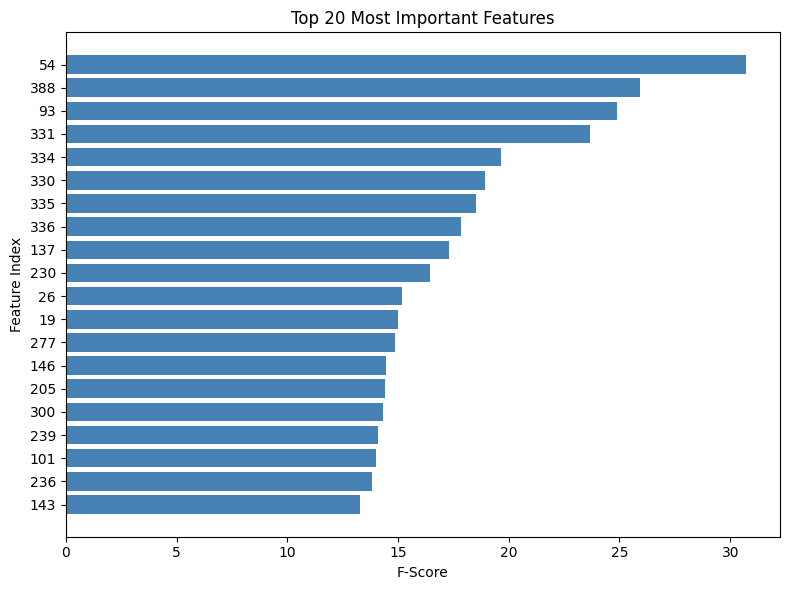

In [6]:
# Visualize top 20 feature scores
plt.figure(figsize=(8, 6))
top20 = feature_scores.head(20)
plt.barh(top20['feature'].astype(str), top20['score'], color='steelblue')
plt.xlabel('F-Score')
plt.ylabel('Feature Index')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

In [7]:
import numpy as np

np.save('../data/processed/X_train_selected.npy', X_train_selected)
np.save('../data/processed/X_test_selected.npy', X_test_selected)
np.save('../data/processed/y_train.npy', y_train.values)
np.save('../data/processed/y_test.npy', y_test.values)

print("Preprocessed data saved successfully!")

Preprocessed data saved successfully!


In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=69)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print("Before SMOTE:")
print(f"  Fail (0): {sum(y_train == 0)}")
print(f"  Pass (1): {sum(y_train == 1)}")

print("\nAfter SMOTE:")
print(f"  Fail (0): {sum(y_train_smote == 0)}")
print(f"  Pass (1): {sum(y_train_smote == 1)}")

Before SMOTE:
  Fail (0): 1170
  Pass (1): 83

After SMOTE:
  Fail (0): 1170
  Pass (1): 1170


/Users/zabir/Documents/SemiSight/semisight_env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [9]:
np.save('../data/processed/X_train_smote.npy', X_train_smote)
np.save('../data/processed/y_train_smote.npy', y_train_smote)

#SMOTE data saved

In [10]:
print(f"\nTraining samples (SMOTE): {len(X_train_smote)}")
print(f"Test samples (real):      {len(X_test_selected)}")
print(f"\nTraining class balance:")
print(f"  Fail: {sum(y_train_smote == 0)} | Pass: {sum(y_train_smote == 1)}")
print(f"\nTest class balance:")
print(f"  Fail: {sum(y_test == 0)} | Pass: {sum(y_test == 1)}")


Training samples (SMOTE): 2340
Test samples (real):      314

Training class balance:
  Fail: 1170 | Pass: 1170

Test class balance:
  Fail: 293 | Pass: 21
